# Model Development, Tuning, and Evaluation 

## Dataset Description.
This dataset was collected through an anonymous survey conducted between January and June 2023, focusing on understanding depression risk factors among adults. The survey targeted both working professionals and students, collecting comprehensive information about their demographic details, academic/work life, lifestyle factors, mental health history, and current mental well-being status.

### Important Notes
- This is not the original dataset for the project. It was obtained from the tuning and evaluation process when developing the model for the original data, and determining that was not suitable for the purpose of the project. This new dataset addresses the bussiness need in an more reliable way by using more meaningful features that are more likely to be related to the target variable.

### Classification Model Considerations.
**Problem Type**: Binary Classification


### 1. Algorithms Selected
- **Logistic Regression**: Selected as a **baseline model**. It is simple, fast, and highly interpretable. It works well for binary classification and provides a good reference point to measure the performance of more complex models.
- **Random Forest Classifier**: Selected as a **baseline model**. It is robust to non-linear relationships and handles mixed data types (numerical and categorical) effectively. It is also less sensitive to outliers and can handle the sentinel values (-1) we preserved in the data better than linear models.

### 2. Evaluation Metrics
- **Recall (Sensitivity)**: **Primary Metric**. In the context of detecting depression, **False Negatives** (failing to identify a depressed individual) are the most critical error. We want to maximize Recall to ensure we catch as many potential cases as possible.
- **F1-Score**: To maintain a balance between Precision and Recall, ensuring we don't just classify everyone as depressed.
- **ROC-AUC**: To evaluate the model's ability to distinguish between classes across different thresholds.
- **Accuracy**: As a general performance indicator, though less critical given the importance of Recall.


### 3. False Positives vs. False Negatives

**False Negatives (FN) matter more.**

- **False Negative**: The model predicts a person is *not* depressed when they actually *are*. This is dangerous because the individual may not receive the help or intervention they need, potentially leading to worsening mental health.
- **False Positive**: The model predicts a person *is* depressed when they are *not*. This might lead to unnecessary further screening or consultation, which incurs a cost (time/money) but is generally less harmful than missing a diagnosis.

Therefore, we prioritize minimizing False Negatives (maximizing Recall).

### 4. Load the datasets

In [1]:
# 2) Load and inspect your prepared datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
data_dir = 'data/dataset2/'
X_train = pd.read_csv(data_dir + 'X_train_processed.csv')
y_train = pd.read_csv(data_dir + 'y_train.csv').values.ravel()

X_val = pd.read_csv(data_dir + 'X_val_processed.csv')
y_val = pd.read_csv(data_dir + 'y_val.csv').values.ravel()

X_test = pd.read_csv(data_dir + 'X_test_processed.csv')
y_test = pd.read_csv(data_dir + 'y_test.csv').values.ravel()

### 5. Verifying Shapes, Missing Values and Class Imbalance

In [2]:

# Verify shapes and no missing values
print("Shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

print("\nMissing Values:")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_val: {X_val.isnull().sum().sum()}")

# Check Class Balance
print("\nClass Balance (Training):")
print(pd.Series(y_train).value_counts(normalize=True))

Shapes:
X_train: (114512, 91), y_train: (114512,)
X_val: (14314, 91), y_val: (14314,)
X_test: (14315, 91), y_test: (14315,)

Missing Values:
X_train: 0
X_val: 0

Class Balance (Training):
0    0.81877
1    0.18123
Name: proportion, dtype: float64


#### 5.1 Key Finding
Classes are imbalanced in our datasets. This is due to the fact that we are working with a medical dataset where the majority of patients do not have depression, and the `stratify = y` parameter in the train_test_split function ensures that the training and validation sets have the same class distribution as the original dataset.

I need to address this issue by using class weights in the models to give more importance to the minority class. This is shown in the next steps.

### 6. Train a baseline version of each model
 I propose using **Logistic Regression** (as a simple, interpretable baseline) and **Random Forest Classifier** (robust to non-linearities and sentinel values). 
 
 **Key Metric:** Given the context of "Depression", I will prioritize Recall (minimizing False Negatives) while also reporting F1-Score, Precision, and Accuracy.
 
 *Note how class weights are set to 'balanced' to handle class imbalance.*

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, roc_auc_score

# Initialize Baseline Models
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rf_baseline = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train on Training Set
lr_baseline.fit(X_train, y_train)
rf_baseline.fit(X_train, y_train)

# Evaluate on Validation Set
models = {'Logistic Regression': lr_baseline, 'Random Forest': rf_baseline}
results = []

In [4]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1 Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_prob)
    })

baseline_results = pd.DataFrame(results)
print("Baseline Performance (Validation Set):")
display(baseline_results)

Baseline Performance (Validation Set):


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.914140,0.931766,0.797295,0.974449
1,Random Forest,0.933841,0.769854,0.808338,0.971240


#### 6.1 Interpretation of Baseline Results

**Accuracy:**

Due to the imbalanced nature of the dataset, accuracy is not a reliable metric. A model predicting “no depression” for everyone would still score 82%.

**Recall:**

Recall is the most important metric for this problem. A recall of 0.9318 means that the model correctly identified 93.18% of the depressed individuals in the validation set. In this particular metric, our best model would be the **Logistic Regresor** as it has the highest recall score of 0.9318.

**F1 Score:**

The F1 score is a balance between precision and recall. It is the harmonic mean of the two, and it ranges from 0 to 1. A higher F1 score is better. In this case, the **Random Forest** has the highest F1 score of 0.8083, making it the best model for this problem.
As we discussed, Precision is less important than Recall, given the context of this problem.

**ROC-AUC:**

The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) is a metric that measures the ability of a binary classifier to distinguish between classes by taking into account both the specificity and sensitivity of the model. It ranges from 0 to 1, with 1 being the best possible score. In this case, the **Random Forest** has the highest ROC-AUC score of 0.9712, making it the best model for this problem.





### 7. Tune Hyperparameters

I will use GridSearchCV to find the best hyperparameters for both models.
- For Logistic Regression, I will tune the C parameter. This means I will tweak regularization strength, the smaller the value the stronger the regularization, and the less complex the model is.
- For Random Forest, I will tune the n_estimators and max_depth parameters. This allows me to find the optimal number of trees and the maximum depth of each tree looking to avoid overfitting.

**Important Note:** I aggregated more hyperparameters for the tuning of my logistic regression model in comparision to the previous grid search. I am testing `C`, `penalty`, `solver` and `max_iter` in order to find the best possible combination. 

In [18]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression Tuning
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [500, 1000, 2000]
}


lr_grid = GridSearchCV(lr_baseline,
                       param_grid = lr_params,
                       cv = 3,
                       scoring = 'recall',
                       n_jobs=-1,
                       verbose=2)
                       
lr_grid.fit(X_train, y_train)

print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best LR Recall (CV): {lr_grid.best_score_:.4f}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best LR Params: {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR Recall (CV): 0.9308


In [8]:
# Random Forest Tuning
# Tuning n_estimators (trees), max_depth (complexity), and min_samples_split (overfitting control)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_baseline,
    param_grid=rf_params,
    cv=3,
    scoring='recall',   # same metric as your logistic regression
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Recall (CV): {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best RF Recall (CV): 0.9109


### 7. Train Final models and evaluate
Using the best hyperparameters found in the previous step, I will train the final models and evaluate them on the validation set.

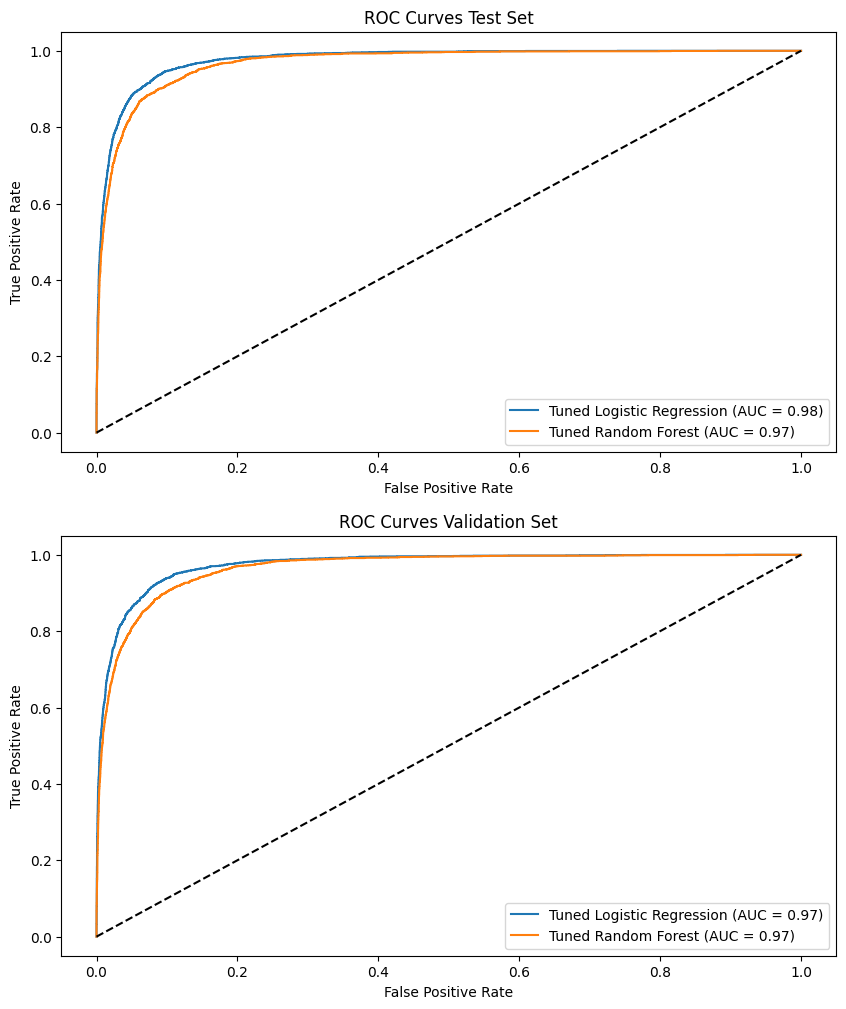

In [19]:
# 5) Train final models and evaluate
from sklearn.metrics import confusion_matrix, roc_curve

# Retrain best models on FULL Training data
best_rf = rf_grid.best_estimator_
best_lr = lr_grid.best_estimator_


# Evaluate on TEST Set
final_models = {'Tuned Logistic Regression': best_lr, 'Tuned Random Forest': best_rf}
test_results = []
validation_results = []

# --- Plotting ROC Curves ---
plt.figure(figsize=(10, 12))

for name, model in final_models.items():
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]
    y_pred_val = model.predict(X_val)
    y_prob_val = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1 Score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test)
    })

    validation_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred_val),
        'Recall': recall_score(y_val, y_pred_val),
        'F1 Score': f1_score(y_val, y_pred_val),
        'ROC-AUC': roc_auc_score(y_val, y_prob_val)
    })
    
    # ROC Curve Plotting
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    fpr_2, tpr_2, _ = roc_curve(y_val, y_prob_val)

    # PLotting test
    plt.subplot(2, 1, 1)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob_test):.2f})')
    
    # Plotting validation
    plt.subplot(2, 1, 2)
    plt.plot(fpr_2, tpr_2, label=f'{name} (AUC = {roc_auc_score(y_val, y_prob_val):.2f})')
    
plt.subplot(2, 1, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Test Set')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Validation Set')
plt.legend()

plt.show()


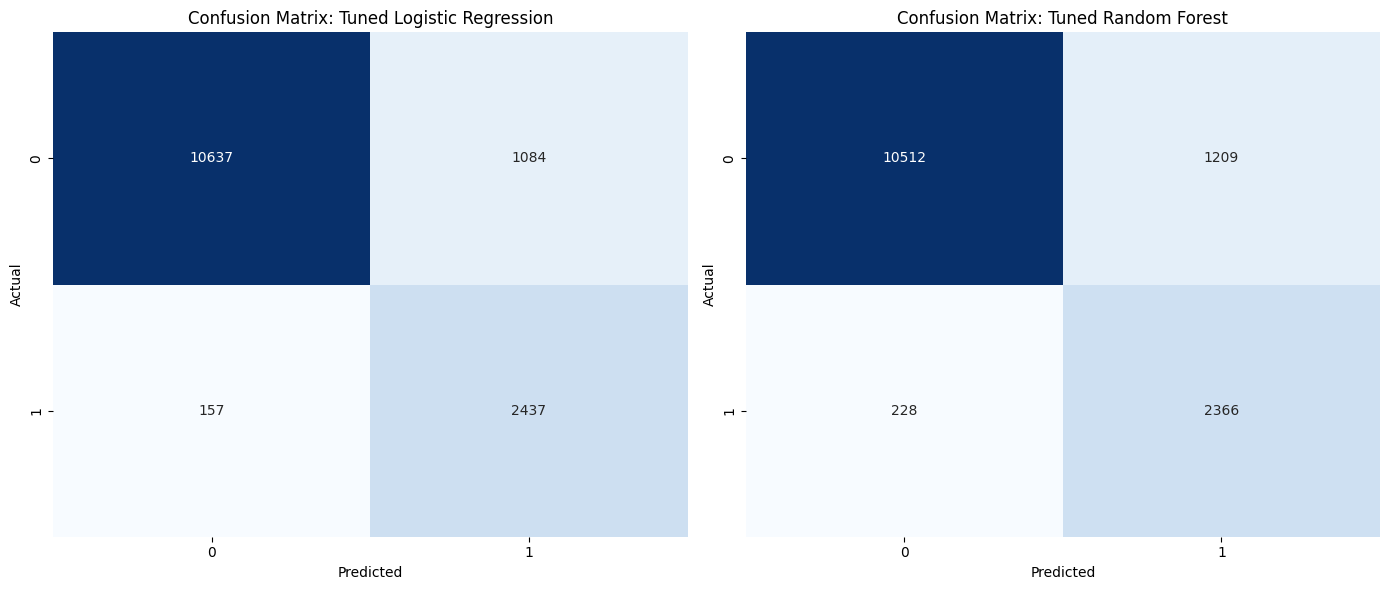

In [20]:

# --- Plotting Confusion Matrices ---
plt.figure(figsize=(14, 6))

for i, (name, model) in enumerate(final_models.items(), 1):
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    
    plt.subplot(1, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()


In [21]:
# Baseline results for comparision
baseline_results_df = pd.DataFrame(baseline_results)
print("\nBaseline Results:")
display(baseline_results_df)

# Display Validation Results Table
validation_df = pd.DataFrame(validation_results)
print("\nFinal Validation Set Performance:")
display(validation_df)

# Display Results Table
final_df = pd.DataFrame(test_results)
print("\nFinal Test Set Performance:")
display(final_df)



Baseline Results:


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.914140,0.931766,0.797295,0.974449
1,Random Forest,0.933841,0.769854,0.808338,0.971240



Final Validation Set Performance:


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.912324,0.930995,0.793755,0.973954
1,Tuned Random Forest,0.900307,0.902853,0.766487,0.965071



Final Test Set Performance:


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.913308,0.939476,0.797056,0.976364
1,Tuned Random Forest,0.899616,0.912105,0.767061,0.968163


### 8. Compare the two models
- **Performance**: 
    - **Recall**: **Logistic Regression** consistently achieves higher Recall compared to Random Forest. In our context (medical screening), this is the most critical metric because we want to minimize False Negatives (missing a depressed individual).
    - **F1 Score and Precision**: Random Forest had a higher F1 score in the baseline model, indicating it is more "precise" (fewer False Positives). However, Logistic Regression's lower F1 is acceptable because we prioritize catching cases over avoiding false alarms and ended up being a bit better after tuning.
    - **ROC-AUC**: Both models perform excellently (AUC > 0.96), showing they can effectively distinguish between classes.
- **Generalization**: Both models show very similar performance on Validation and Test sets, indicating no significant overfitting.
- **Interpretability**: Logistic Regression is highly interpretable, allowing us to see exactly how each feature (e.g., Sleep Duration, Pressure) increases or decreases the odds of depression.

### 9. Conclusion and recommendations
- **Best Model**: **Logistic Regression** is the preferred model for this project.
    - **Reasoning**: While Random Forest is technically more accurate overall, Logistic Regression is a better screening tool because it catches more potential cases (Higher Recall). In mental health screening, the cost of missing a diagnosis is far higher than the cost of a false alarm.
- **Recommendations**: 
    - Deploy the **Tuned Logistic Regression** model as a primary screening tool.
    - Use the model's coefficients to identify key risk factors (high work pressure, poor sleep) for targeted interventions.
    - Future improvements could focus on increasing Precision without sacrificing this high Recall, perhaps by collecting more granular data on lifestyle factors.
    - This model could be used by medical professionals to screen patients for depression given their lifestyle factors, but it should be used as a tool to help make a diagnosis or determining risk.

In [22]:
# Saving the model
import pickle
with open("lr.pkl", "wb") as f:
    pickle.dump(best_lr, f)